# 09 · Calibration — Are the Uncertainties Honest?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/09_calibration.ipynb)

An uncertainty estimate is only useful if it's calibrated. We measure interval coverage of the ensemble on held-out I–V, find it **overconfident** (a known small-ensemble failure), and fix it with temperature scaling.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.11.0+cu128


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

from bayespinn_inv.surrogate import (SymlogTransform, Normalizer, IVSurrogate,
    IVSurrogateConfig, build_sg_dataset, train_surrogate, SurrogateEnsemble)
from math import erf, sqrt
symlog = SymlogTransform(I0=1e-6); biases = np.linspace(0.0, 0.6, 13)
profiles=[step(L) for L in np.geomspace(5e20,5e22,11)]
X,Y=build_sg_dataset(profiles,biases,scaling,sg,symlog); norm=Normalizer.fit(X)
members=[]
for m in range(5):
    net=IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR,hidden=128,n_layers=3,seed=m))
    rs=np.random.RandomState(m); idx=rs.randint(0,len(X),len(X))
    train_surrogate(net,X[idx],Y[idx],norm,epochs=2000,lr=2e-3); members.append(net)
ens=SurrogateEnsemble(members,norm,symlog)
def nominal(z): return erf(z/sqrt(2))


## Coverage before and after recalibration

temperature T=2.57
interval    raw  recal  nominal
± 1.0σ    20%    62%      68%
±1.64σ    40%    83%      90%
± 2.0σ    47%    87%      95%


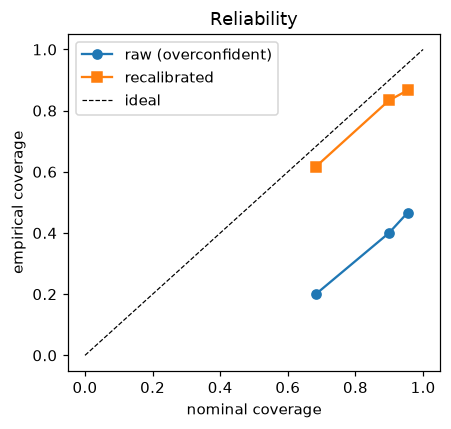

In [3]:

def z_scores(levels):
    zs=[]
    for L in levels:
        C=step(L); pred=ens.predict(scaling.doping_to_net_input(C), biases/VT)
        Isg=sg_iv(C,biases)
        for bi,V in enumerate(biases):
            if V<0.1: continue
            s=pred.std_symlog[bi]
            if s>1e-9: zs.append((symlog.forward(Isg[bi])-pred.mean_symlog[bi])/s)
    return np.array(zs)
zv=z_scores(np.geomspace(6e20,4e22,6)); zt=z_scores(np.geomspace(9e20,3e22,6))
T=max(float(np.quantile(np.abs(zv),nominal(1.0))),1e-3)
zlist=[1.0,1.64,2.0]
print(f"temperature T={T:.2f}")
print(f"{'interval':>8} {'raw':>6} {'recal':>6} {'nominal':>8}")
raw=[]; recal=[]; nom=[]
for z in zlist:
    r=float(np.mean(np.abs(zt)<=z)); c=float(np.mean(np.abs(zt)<=z*T)); n=nominal(z)
    raw.append(r); recal.append(c); nom.append(n)
    print(f"±{z:>4}σ {r:6.0%} {c:6.0%} {n:8.0%}")
plt.figure(figsize=(4.2,4))
plt.plot(nom, raw, "o-", label="raw (overconfident)")
plt.plot(nom, recal, "s-", label="recalibrated")
plt.plot([0,1],[0,1],"k--", lw=0.8, label="ideal")
plt.xlabel("nominal coverage"); plt.ylabel("empirical coverage")
plt.legend(); plt.title("Reliability"); plt.tight_layout(); plt.show()
